# Start of Plot Creation

In [ ]:
#Libraries
import rasterio as rast
import rasterio.mask
from rasterio.plot import show
from rasterio.enums import ColorInterp
from rasterio.transform import xy
import geopandas as gpd
import pandas as pd
import numpy as np
import scipy as sc
import matplotlib.pyplot as plt
from scipy.ndimage import generic_filter
from pyproj import Transformer
from shapely import Point
import google.colab.drive

In [ ]:
#import files
buffer = gpd.read_file("/content/drive/MyDrive/SilvX Labs - Internship/Roads_Buffers_Map2.gpkg",
                       layer='Buffers')
#buffer = gpd.read_file("/content/drive/MyDrive/SilvX Labs - Internship/Validation_Plots_Final.gpkg",
                       #layer='0.5Mile_Buffer')
predictions = rast.open("/content/drive/Shareddrives/FSE-MSO-Validation/FSE_artifacts_M332_B_g_inference_M332Bg_multiband_mosaic.tif")
#predictions = rast.open("/content/drive/MyDrive/SilvX Labs - Internship/lolo_nf_lolo_nf_inference_CORE_VARS_lolo_nf_16_mosaic.tif")

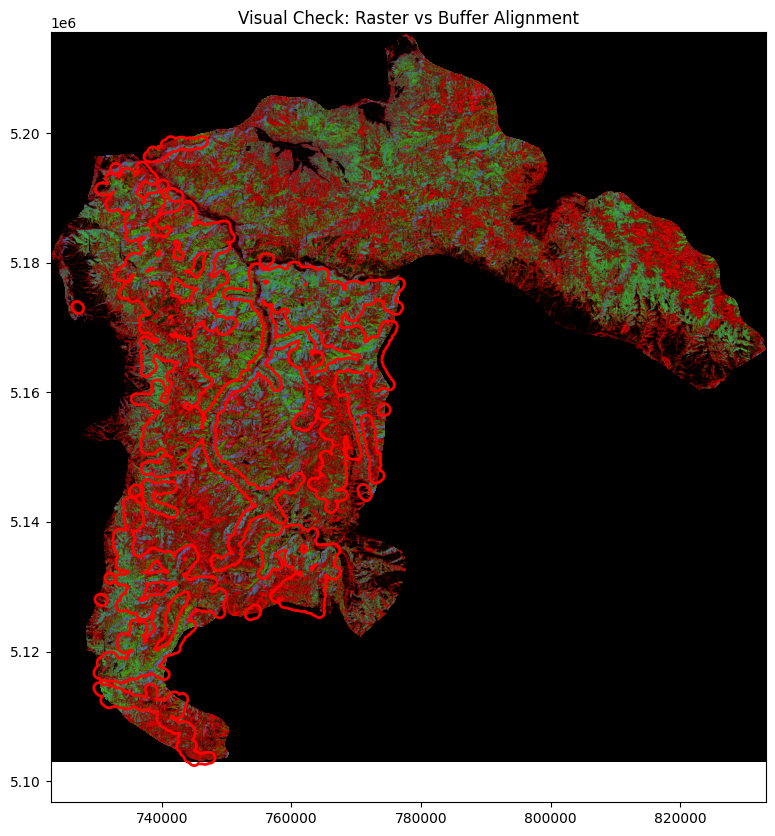

In [ ]:
#align CRS
crs = predictions.crs
buffer = buffer.to_crs(crs)

#dissolve buffer
buffer = buffer.dissolve()

#check
fig, ax = plt.subplots(figsize=(10, 10))

show(predictions, ax=ax, cmap='terrain')

buffer.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=2)

plt.title("Visual Check: Raster vs Buffer Alignment")
plt.show()

In [ ]:
#Check Available Bands and pick one
print("Number of bands:", predictions.count)
print("Band Indexes:", predictions.indexes)
print("Band Descriptions:", predictions.descriptions)
print("Basal Area All Index: ", predictions.descriptions.index('basal_area_total'))
selected_band = 35

Number of bands: 52
Band Indexes: (1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52)
Band Descriptions: ('FORTYPCD', 'max_ht_live', 'tpa_over5_live', 'basal_area_all_live', 'qmd_all_live', 'total_volcfnet_pa', 'total_drybio_ag_pa', 'canopy_cover_frac', 'tpa_dbh_0_5', 'tpa_dbh_5_10', 'tpa_dbh_10_15', 'tpa_dbh_15_20', 'tpa_dbh_20_25', 'tpa_dbh_25_30', 'tpa_dbh_30_999', 'tpa_ht_0_5', 'tpa_ht_5_10', 'tpa_ht_10_15', 'tpa_ht_15_20', 'tpa_ht_20_25', 'tpa_ht_25_30', 'tpa_ht_30_999', 'ht_p10', 'ht_p25', 'ht_p50', 'ht_p75', 'ht_p90', 'ht_max', 'mean_crown_ratio', 'tpa_live', 'tpa_dead', 'tpa_total', 'mortality_tpa_frac', 'basal_area_live', 'basal_area_dead', 'basal_area_total', 'mortality_ba_frac', 'qmd_live', 'qmd_dead', 'is_synthetic_empty', 'fortype_0', 'fortype_201', 'fortype_221', 'fortype_266', 'fortype_268', 'fortype_281', 'fortype_321', 'for

In [ ]:
#clip raster to 0.5mile buffer

nodata = predictions.nodata

# Clip raster (returns a tuple: (array, transform))
clipped_predictions, clipped_transform = rasterio.mask.mask(
    predictions,
    buffer.geometry,
    crop=True,
    filled=True,
    nodata=nodata
)

# Convert to float for NaN handling
clipped_float = clipped_predictions[selected_band].astype("float32")

# Replace nodata with np.nan
if nodata is not None:
    clipped_float[clipped_float == nodata] = np.nan

In [ ]:
#mask values outside desired range

min_val_ig = 35
max_val_ig = 60
min_val_og = 60
max_val_og = 85

#output for oldgrowth
desired_og = np.where(
    (clipped_float >= min_val_og) & (clipped_float <= max_val_og),
    clipped_float,
    np.nan
)

#output for intermediate growth
desired_ig = np.where(
    (clipped_float >= min_val_ig) & (clipped_float < max_val_ig),
    clipped_float,
    np.nan
)

In [ ]:
#compute neighbor pixel similarity

#function creation
def similar_neighbors(window):
    center = window[len(window)//2]
    if np.isnan(center):
      return 0
    return np.sum(np.isnan(window))

#neighbor ID for oldgrowth
similarity_og = generic_filter(
    desired_og,
    similar_neighbors,
    size = 3,
    mode="constant",
    cval=np.nan
)

homogeneous_og = np.where(
    similarity_og == 0,
    desired_og,
    np.nan
    ).astype("float32")

#neighbor ID for intermediate growth
similarity_ig = generic_filter(
    desired_ig,
    similar_neighbors,
    size = 3,
    mode="constant",
    cval=np.nan
)

homogeneous_ig = np.where(
    similarity_ig == 0,
    desired_ig,
    np.nan
    ).astype("float32")

In [ ]:
#export oldgrowth raster

out_meta = predictions.meta.copy()
out_meta.update({
    "height": desired_og.shape[0],
    "width": desired_og.shape[1],
    "count": 1,
    "dtype": "uint8",
    "transform": clipped_transform,
    "nodata": 0
})

with rasterio.open(f"BA-All-3x3_og.tif", "w", **out_meta) as dst:
    dst.write(desired_og, 1)

#export intermediate growth raster

out_meta = predictions.meta.copy()
out_meta.update({
    "height": desired_ig.shape[0],
    "width": desired_ig.shape[1],
    "count": 1,
    "dtype": "uint8",
    "transform": clipped_transform,
    "nodata": 0
})

with rasterio.open(f"BA-All-3x3_ig.tif", "w", **out_meta) as dst:
    dst.write(desired_ig, 1)

In [ ]:
#load eligible pixel raster
input_path_og = "/content/BA-All-3x3_og.tif"
input_path_ig = "/content/BA-All-3x3_ig.tif"
output_path_og = "/content/og_plots.tif"
output_path_ig = "/content/ig_plots.tif"

# Open old growth raster
with rasterio.open(input_path_og) as og:
    raster_og = og.read(1)
    profile_og = og.profile
    transform_og = og.transform
    crs_og = og.crs

# Open intermediate growth raster
with rasterio.open(input_path_ig) as ig:
    raster_ig = ig.read(1)
    profile_ig = ig.profile
    transform_ig = ig.transform
    crs_ig = ig.crs

In [ ]:
#Pixel Eligibility Masks

eligible_mask_og = (raster_og >= 60) & (raster_og <= 85)
eligible_mask_ig = (raster_ig >= 35) & (raster_ig <60)

In [ ]:
#random sample eligible pixles

#old growth
rows_og, cols_og = np.where(eligible_mask_og)

percentage = 0.01
n_select_og = int(len(rows_og) * percentage)

selected_idx_og = np.random.choice(
    len(rows_og),
    size=n_select_og,
    replace=False
)

#intermediate growth
rows_ig, cols_ig = np.where(eligible_mask_ig)

percentage = 0.01
n_select_ig = int(len(rows_ig) * percentage)

selected_idx_ig = np.random.choice(
    len(rows_ig),
    size=n_select_ig,
    replace=False
)

In [ ]:
#Create Masks
#old growth
plot_mask_og = np.zeros_like(raster_og, dtype=np.uint8)
plot_mask_og[rows_og[selected_idx_og], cols_og[selected_idx_og]] = 1

#intermediate growth
plot_mask_ig = np.zeros_like(raster_ig, dtype=np.uint8)
plot_mask_ig[rows_ig[selected_idx_ig], cols_ig[selected_idx_ig]] = 1

#impliment
raster_og = raster_og.astype(float)  # convert to float for NaN
masked_raster_og = np.where(plot_mask_og == 1, raster_og, np.nan)

raster_ig = raster_ig.astype(float)  # convert to float for NaN
masked_raster_ig = np.where(plot_mask_ig == 1, raster_ig, np.nan)

In [ ]:
#Export masked rasters

#old growth
profile_og.update(dtype=rasterio.float32, nodata=np.nan, count=1)
with rasterio.open(output_path_og, "w", **profile_og) as dst:
    dst.write(masked_raster_og.astype(rasterio.float32), 1)

print("Selected pixels:", plot_mask_og.sum())
print("Masked raster exported!")

#intermediate growth
profile_ig.update(dtype=rasterio.float32, nodata=np.nan, count=1)
with rasterio.open(output_path_ig, "w", **profile_ig) as dst:
    dst.write(masked_raster_ig.astype(rasterio.float32), 1)

print("Selected pixels:", plot_mask_ig.sum())
print("Masked raster exported!")

Selected pixels: 1172
Masked raster exported!
Selected pixels: 1679
Masked raster exported!


In [ ]:
#extract coordinate locations at plot pixels and transform to lat long

#old growth
rows_selected_og, cols_selected_og = np.where(plot_mask_og == 1)
xs_og, ys_og = xy(transform_og,
            rows_selected_og,
            cols_selected_og,
            offset='center'
)

transformer_og = Transformer.from_crs(crs_og, "EPSG:4326", always_xy=True)
lons_og, lats_og = transformer_og.transform(xs_og, ys_og)

#intermediate growth
rows_selected_ig, cols_selected_ig = np.where(plot_mask_ig == 1)
xs_ig, ys_ig = xy(transform_ig,
            rows_selected_ig,
            cols_selected_ig,
            offset='center'
)

transformer_ig = Transformer.from_crs(crs_ig, "EPSG:4326", always_xy=True)
lons_ig, lats_ig = transformer_ig.transform(xs_ig, ys_ig)


In [ ]:
#save to CSV
output_csv_og = "/content/og_latlong.csv"
output_csv_ig = "/content/ig_latlong.csv"

#old growth
df_og = pd.DataFrame({
    "x_utm": xs_og,
    "y_utm": ys_og,
    "longitude": lons_og,
    "latitude": lats_og
})

df_og.to_csv(output_csv_og, index=False)
print("Plot locations CSV exported:", output_csv_og)

#intermediate growth
df_ig = pd.DataFrame({
    "x_utm": xs_ig,
    "y_utm": ys_ig,
    "longitude": lons_ig,
    "latitude": lats_ig
})

df_ig.to_csv(output_csv_ig, index=False)
print("Plot locations CSV exported:", output_csv_ig)

Plot locations CSV exported: /content/og_latlong.csv
Plot locations CSV exported: /content/ig_latlong.csv


# Start of Validation

In [ ]:
#libraries
import pandas as pd
from google.colab import drive
import numpy as np
import geopandas as gpd
import rasterio as rast
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error

#shortcuts to folders within drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#files

plot_data = pd.read_csv("/content/drive/MyDrive/SilvX Labs - Internship/GNSS-Plot Data/MASTER PLOT DATA SHEET - Sheet1.csv")
plot_cords = pd.read_csv("/content/drive/MyDrive/SilvX Labs - Internship/GNSS-Plot Data/MASTER PLOT COORDINATE SHEET - PLOT_COORDINATES.csv")
map = rast.open("/content/drive/Shareddrives/FSE-MSO-Validation/lolo_nf_lolo_nf_inference_CORE_VARS_lolo_nf_16_mosaic.tif")

In [ ]:
#prep original plot data for summarization
BAF = 10
plot_data['Basal Area/tree'] = 0.005454 * plot_data['DBH']**2
plot_data['TPA'] = BAF / plot_data['Basal Area/tree']
plot_data['BA/acre'] = plot_data['DBH'].notna() * BAF

#clear whitespace
plot_data['Live/Dead'] = plot_data['Live/Dead'].str.strip()

plot_data.head(30)

,Plot ID,Tree #,Species,DBH,Live/Dead,Notes,Basal Area/tree,TPA,BA/acre
0,252,1.0,DF,14.3,LIVE,Within recent thinning,1.115288,8.966290,10
1,252,2.0,DF,12.0,LIVE,NaN,0.785376,12.732755,10
2,252,3.0,DF,10.4,LIVE,NaN,0.589905,16.951892,10
3,252,4.0,PP,13.5,LIVE,NaN,0.993991,10.060448,10
4,252,5.0,DF,8.8,LIVE,NaN,0.422358,23.676610,10
5,252,6.0,DF,13.7,LIVE,NaN,1.023661,9.768857,10
6,252,7.0,DF,12.7,LIVE,NaN,0.879676,11.367826,10
7,252,8.0,DF,14.4,LIVE,NaN,1.130941,8.842191,10
8,252,9.0,DF,13.7,LIVE,NaN,1.023661,9.768857,10
9,252,10.0,DF,9.9,LIVE,NaN,0.534547,18.707445,10


In [ ]:
#create blank df to start plot summaries table

df = pd.DataFrame(columns=['Plot ID', 'TPA', 'TPA Live', 'TPA Dead', 'BA/acre', 'QMD', 'Predicted TPA', 'Predicted TPA Live', 'Predicted TPA Dead', 'Predicted BA/acre', 'Predicted QMD', 'Latitude', 'Longitude'])

#Add in plot IDs
df['Plot ID'] = plot_data['Plot ID'].unique()

#Populate TPA
df['TPA'] = df['Plot ID'].map(
    plot_data.groupby('Plot ID')['TPA'].sum()
)

#Populate BA/acre
df['BA/acre'] = df['Plot ID'].map(
    plot_data.groupby('Plot ID')['BA/acre'].sum()
)

#Populate QMD
df['QMD'] = (np.sqrt((df['BA/acre']) / (df['TPA'] * 0.005454))).round(2)

#Populate TPA Alive
df['TPA Live'] = df['Plot ID'].map(
    plot_data[plot_data['Live/Dead'] == 'LIVE']
    .groupby('Plot ID')['TPA'].sum()
)
#Populate TPA Dead
df['TPA Dead'] = df['Plot ID'].map(
    plot_data[plot_data['Live/Dead'] == 'DEAD']
    .groupby('Plot ID')['TPA'].sum()
)

#populate lat and long
df['Latitude'] = df['Plot ID'].map(
    plot_cords.groupby('Plot ID')['Latitude'].first()
)
df['Longitude'] = df['Plot ID'].map(
    plot_cords.groupby('Plot ID')['Longitude'].first()
)

df

,Plot ID,TPA,TPA Live,TPA Dead,BA/acre,QMD,Predicted TPA,Predicted TPA Live,Predicted TPA Dead,Predicted BA/acre,Predicted QMD,Latitude,Longitude
0,252,149.934348,149.934348,NaN,110,11.60,NaN,NaN,NaN,NaN,NaN,46.756035,-114.161578
1,253,257.711835,257.711835,NaN,60,6.53,NaN,NaN,NaN,NaN,NaN,46.755514,-114.162108
2,179,33.001301,NaN,33.001301,20,10.54,NaN,NaN,NaN,NaN,NaN,46.759375,-114.201320
3,178,0.000000,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,46.765150,-114.201849
4,228,389.790538,389.790538,NaN,40,4.34,NaN,NaN,NaN,NaN,NaN,47.004616,-113.739325
5,229,910.949148,910.949148,NaN,30,2.46,NaN,NaN,NaN,NaN,NaN,46.999404,-113.708529
6,237,1463.778480,1463.778480,NaN,70,2.96,NaN,NaN,NaN,NaN,NaN,46.990498,-113.689267
7,222,148.427012,148.427012,NaN,70,9.30,NaN,NaN,NaN,NaN,NaN,47.027584,-113.687406
8,145,17.125618,13.942429,3.183189,50,23.14,NaN,NaN,NaN,NaN,NaN,47.053784,-114.172010
9,151,48.512983,30.388989,18.123994,120,21.30,NaN,NaN,NaN,NaN,NaN,47.049792,-114.172651


In [ ]:
#convert to geodataframe

gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df['Longitude'], df['Latitude'])
)
gdf.set_crs(epsg=4326, inplace=True)
gdf = gdf.to_crs("EPSG:26911")

In [ ]:
#identify bands of interest
print("Band Descriptions:", map.descriptions)
print("Index: ", map.descriptions.index('basal_area_all'))

tpa_all_band = 3
tpa_live_band = 4
tpa_dead_band = 5
ba_all_band = 12
qmd_all_band = 4

Band Descriptions: ('max_ht_all', 'max_ht_live', 'max_ht_dead', 'tpa_all_all', 'tpa_all_live', 'tpa_all_dead', 'tpa_over5_all', 'tpa_over5_live', 'tpa_over5_dead', 'tpa_over17_all', 'tpa_over17_live', 'tpa_over17_dead', 'basal_area_all', 'basal_area_all_live', 'basal_area_all_dead', 'basal_area_over5_all', 'basal_area_over5_live', 'basal_area_over5_dead', 'fortypcd')
Index:  12


In [ ]:
#Sample
coords = [(x, y) for x, y in zip(gdf.geometry.x, gdf.geometry.y)]
samples = list(map.sample(coords))

#add to gdf columns
gdf['Predicted BA/acre'] = [val[ba_all_band] for val in samples]
gdf['Predicted TPA'] = [val[tpa_all_band] for val in samples]
gdf['Predicted TPA Live'] = [val[tpa_live_band] for val in samples]
gdf['Predicted TPA Dead'] = [val[tpa_dead_band] for val in samples]

gdf = gdf.replace(-9999.0, np.nan)
#save to shp file
gdf.to_file("FINAL_DF.gpkg", driver="GPKG")
gdf

,Plot ID,TPA,TPA Live,TPA Dead,BA/acre,QMD,Predicted TPA,Predicted TPA Live,Predicted TPA Dead,Predicted BA/acre,Predicted QMD,Latitude,Longitude,geometry
0,252,149.934348,149.934348,NaN,110,11.60,271.443939,231.132706,40.311230,69.160378,NaN,46.756035,-114.161578,POINT (716767.65 5181966.526)
1,253,257.711835,257.711835,NaN,60,6.53,327.497284,258.325165,69.172127,61.096340,NaN,46.755514,-114.162108,POINT (716729.212 5181907.204)
2,179,33.001301,NaN,33.001301,20,10.54,241.362122,232.385086,8.977027,43.349339,NaN,46.759375,-114.201320,POINT (713719.469 5182228.799)
3,178,0.000000,NaN,NaN,0,NaN,311.492828,295.497314,15.995497,47.055027,NaN,46.765150,-114.201849,POINT (713656.257 5182869.035)
4,228,389.790538,389.790538,NaN,40,4.34,391.282684,340.399017,50.883675,83.687103,NaN,47.004616,-113.739325,POINT (747864.131 5210838.33)
5,229,910.949148,910.949148,NaN,30,2.46,668.217651,624.497437,43.720131,79.243591,NaN,46.999404,-113.708529,POINT (750229.316 5210357.182)
6,237,1463.778480,1463.778480,NaN,70,2.96,525.437622,498.663269,26.774405,78.894241,NaN,46.990498,-113.689267,POINT (751735.422 5209429.423)
7,222,148.427012,148.427012,NaN,70,9.30,347.217377,331.803467,15.413894,67.517883,NaN,47.027584,-113.687406,POINT (751702.432 5213556.123)
8,145,17.125618,13.942429,3.183189,50,23.14,277.881592,214.727982,63.153599,51.081398,NaN,47.053784,-114.172010,POINT (714777.569 5215022.39)
9,151,48.512983,30.388989,18.123994,120,21.30,314.938507,309.681000,5.257504,42.000946,NaN,47.049792,-114.172651,POINT (714744.892 5214577.097)


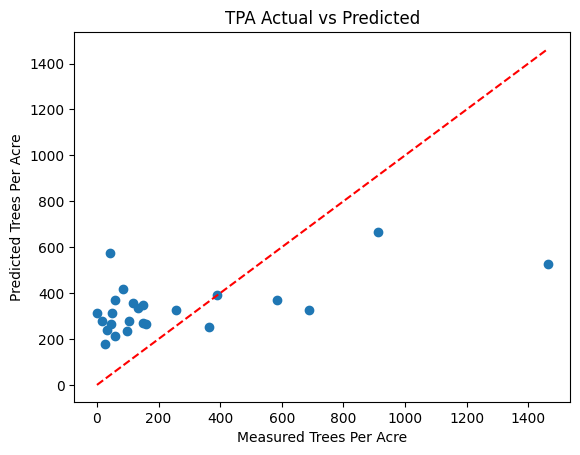

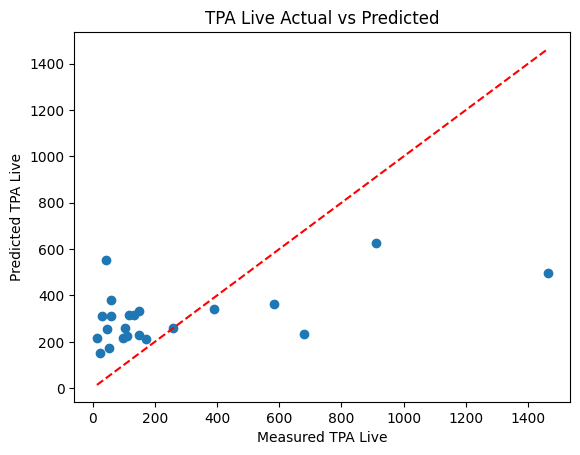

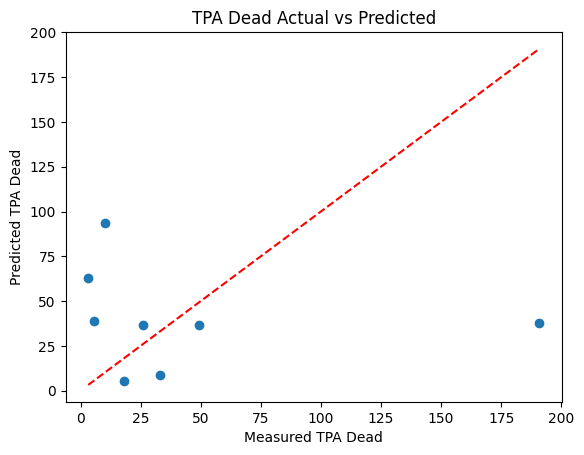

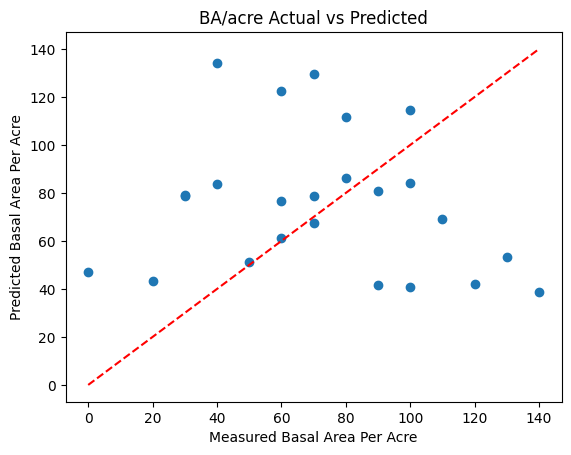

In [ ]:
#plot statistics
import matplotlib.pyplot as plt

# -------------------
# TPA
# -------------------
plt.figure()

plt.scatter(gdf['TPA'], gdf['Predicted TPA'])

plt.xlabel("Measured Trees Per Acre")
plt.ylabel("Predicted Trees Per Acre")
plt.title("TPA Actual vs Predicted")

plt.plot(
    [gdf['TPA'].min(), gdf['TPA'].max()],
    [gdf['TPA'].min(), gdf['TPA'].max()],
    'r--'
)

plt.show()


# -------------------
# TPA Live
# -------------------
plt.figure()

plt.scatter(gdf['TPA Live'], gdf['Predicted TPA Live'])

plt.xlabel("Measured TPA Live")
plt.ylabel("Predicted TPA Live")
plt.title("TPA Live Actual vs Predicted")

plt.plot(
    [gdf['TPA Live'].min(), gdf['TPA Live'].max()],
    [gdf['TPA Live'].min(), gdf['TPA Live'].max()],
    'r--'
)

plt.show()


# -------------------
# TPA Dead
# -------------------
plt.figure()

plt.scatter(gdf['TPA Dead'], gdf['Predicted TPA Dead'])

plt.xlabel("Measured TPA Dead")
plt.ylabel("Predicted TPA Dead")
plt.title("TPA Dead Actual vs Predicted")

plt.plot(
    [gdf['TPA Dead'].min(), gdf['TPA Dead'].max()],
    [gdf['TPA Dead'].min(), gdf['TPA Dead'].max()],
    'r--'
)

plt.show()


# -------------------
# BA / acre
# -------------------
plt.figure()

plt.scatter(gdf['BA/acre'], gdf['Predicted BA/acre'])

plt.xlabel("Measured Basal Area Per Acre")
plt.ylabel("Predicted Basal Area Per Acre")
plt.title("BA/acre Actual vs Predicted")

plt.plot(
    [gdf['BA/acre'].min(), gdf['BA/acre'].max()],
    [gdf['BA/acre'].min(), gdf['BA/acre'].max()],
    'r--'
)

plt.show()

In [ ]:
#More Statistics

def metrics(y_true, y_pred, name):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{name} R²: {r2:.3f}")
    print(f"{name} RMSE: {rmse:.3f}\n")

metrics(gdf['TPA'], gdf['Predicted TPA'], "TPA")
metrics(gdf['TPA Live'], gdf['Predicted TPA Live'], "TPA Live")
metrics(gdf['TPA Dead'], gdf['Predicted TPA Dead'], "TPA Dead")
metrics(gdf['BA/acre'], gdf['Predicted BA/acre'], "BA/acre")

ValueError: Input contains NaN.